### Import

In [2]:
import pandas as pd
from sqlalchemy import create_engine


USER = "postgres"
PASSWORD = "Data25"
HOST = "localhost"
PORT = "5432"
DB_NAME = "Ottimizzazione_funnel"

# Connessione e import
engine = create_engine(f'postgresql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DB_NAME}')

In [3]:
query = "SELECT * FROM user_event_conversion;"
df_vista = pd.read_sql(query, engine)

In [4]:
df_vista.head()

,user_id,event_id,view_date,device_type,country,purchase_timestamp,ticket_price
0,2328,68,2026-01-01 23:41:00,mobile,DE,NaT,NaN
1,9340,58,2026-01-01 22:09:00,mobile,ES,NaT,NaN
2,2812,58,2026-01-01 13:36:00,mobile,DE,NaT,NaN
3,11412,95,2026-01-01 20:20:00,mobile,UK,NaT,NaN
4,2386,103,2026-01-01 19:02:00,mobile,ES,NaT,NaN


In [8]:
df_vista.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170684 entries, 0 to 170683
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   user_id             170684 non-null  int64         
 1   event_id            170684 non-null  int64         
 2   view_date           170684 non-null  datetime64[ns]
 3   device_type         170684 non-null  object        
 4   country             170684 non-null  object        
 5   purchase_timestamp  6246 non-null    datetime64[ns]
 6   ticket_price        6246 non-null    float64       
dtypes: datetime64[ns](2), float64(1), int64(2), object(2)
memory usage: 9.1+ MB


In [10]:
df_vista['purchase_timestamp'].isna().sum()

164438

In [12]:
df_vista['purchase_timestamp'].notna().sum()

6246

In [14]:
df_vista['Tiempo'] = pd.cut(
    df_vista['view_date'],
    bins=2,
    labels=['a_30', 'b_30']
)


### Conversion rate

In [17]:
df_vista

,user_id,event_id,view_date,device_type,country,purchase_timestamp,ticket_price,Tiempo
0,2328,68,2026-01-01 23:41:00,mobile,DE,NaT,NaN,a_30
1,9340,58,2026-01-01 22:09:00,mobile,ES,NaT,NaN,a_30
2,2812,58,2026-01-01 13:36:00,mobile,DE,NaT,NaN,a_30
3,11412,95,2026-01-01 20:20:00,mobile,UK,NaT,NaN,a_30
4,2386,103,2026-01-01 19:02:00,mobile,ES,NaT,NaN,a_30
...,...,...,...,...,...,...,...,...
170679,9665,86,2026-03-02 10:44:00,mobile,ES,NaT,NaN,b_30
170680,7932,53,2026-03-01 19:41:00,mobile,ES,NaT,NaN,b_30
170681,11900,117,2026-03-01 13:36:00,mobile,IT,NaT,NaN,b_30
170682,19276,58,2026-03-02 06:47:00,mobile,FR,NaT,NaN,b_30


In [19]:
df_vista.groupby('Tiempo')['user_id'].count()

Tiempo
a_30    74979
b_30    95705
Name: user_id, dtype: int64

Trafico +28%

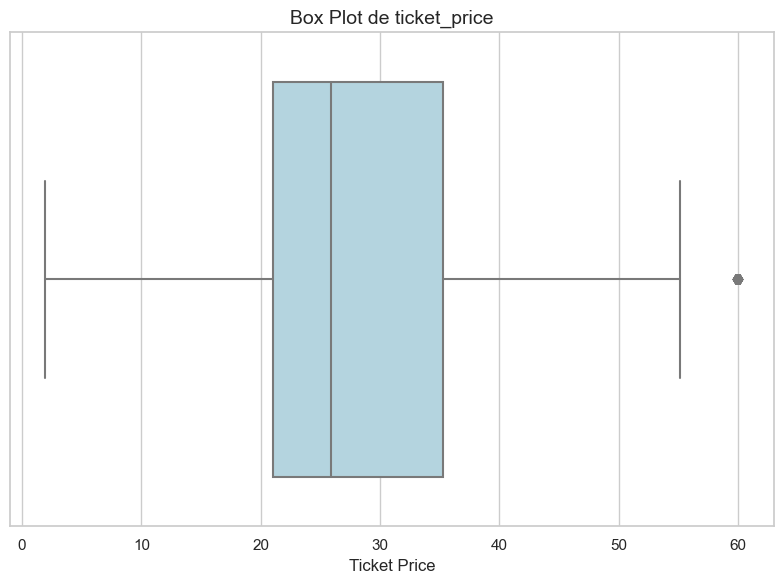

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
sns.set(style="whitegrid")

# Box plot
plt.figure(figsize=(8, 6))
sns.boxplot(x=df_vista['ticket_price'], color='lightblue')


plt.title('Box Plot de ticket_price', fontsize=14)
plt.xlabel('Ticket Price', fontsize=12)


plt.tight_layout()
plt.show()


In [24]:
ticket_price_sum = df_vista.groupby('Tiempo')['ticket_price'].sum().reset_index()
ticket_price_sum


,Tiempo,ticket_price
0,a_30,87545.30
1,b_30,89993.67


In [26]:
# Cálculo de conteos y sumas
result_df = df_vista.groupby('Tiempo').agg(
    user_count=('user_id', 'count'),
    total_ticket_price=('ticket_price', 'sum')
).reset_index()

# Añadir columnas para los recuentos de purchase_timestamp nulos y no nulos.
result_df['null_purchase'] = df_vista.groupby('Tiempo')['purchase_timestamp'].apply(lambda x: x.isna().sum()).values
result_df['non_null_purchase'] = df_vista.groupby('Tiempo')['purchase_timestamp'].apply(lambda x: x.notna().sum()).values
result_df

,Tiempo,user_count,total_ticket_price,null_purchase,non_null_purchase
0,a_30,74979,87545.30,71917,3062
1,b_30,95705,89993.67,92521,3184


In [28]:
result_df['cr'] = (result_df['non_null_purchase'] / result_df['user_count']) * 100
result_df

,Tiempo,user_count,total_ticket_price,null_purchase,non_null_purchase,cr
0,a_30,74979,87545.30,71917,3062,4.08381
1,b_30,95705,89993.67,92521,3184,3.32689


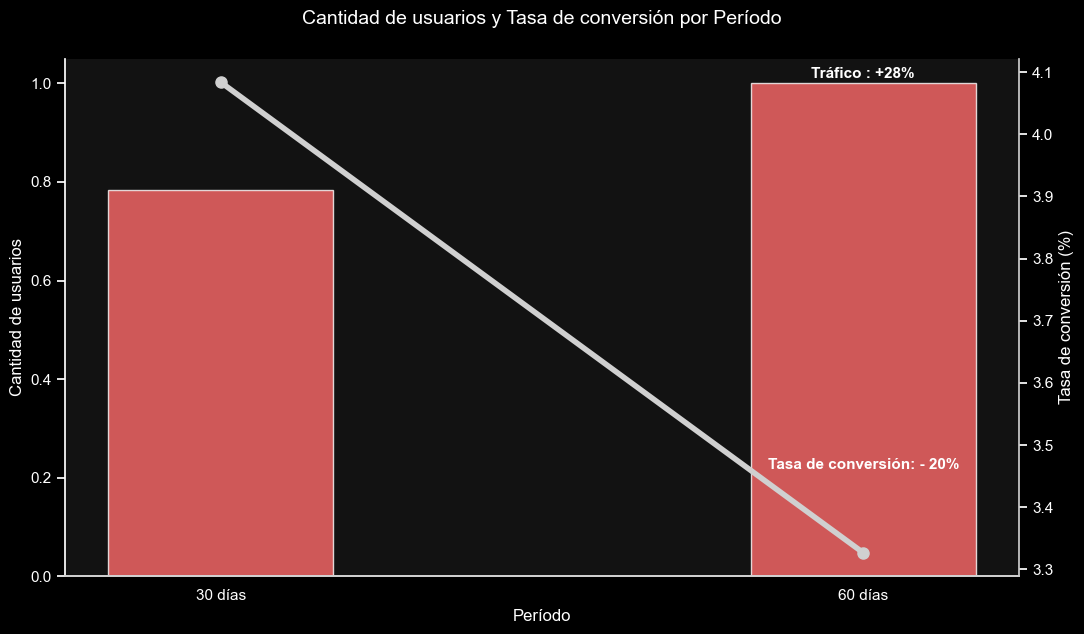

In [30]:
import matplotlib.pyplot as plt

# --- PREPARACIÓN DE DATOS ---
# Asignación de etiquetas para el eje X
mapping = {'a_30': '30 días', 'b_30': '60 días'}
result_df['Tiempo'] = result_df['Tiempo'].replace(mapping)

# Normalización de user_count (escalar los valores)
result_df['user_count_norm'] = result_df['user_count'] / result_df['user_count'].max()

# --- CREACIÓN GRÁFICA ---
fig, ax1 = plt.subplots(figsize=(11, 6.5), facecolor='black')
ax1.set_facecolor('#121212')

# Gráfico de barras para user_count (normalizados)
bars = ax1.bar(
    result_df['Tiempo'],
    result_df['user_count_norm'],
    color='#FF6B6B',
    alpha=0.8,
    width=0.35,
    label='Usuarios (norm)'
)

# Configuración de ejes (X e Y1)
ax1.set_xlabel('Período', color='white', fontsize=12)
ax1.set_ylabel('Cantidad de usuarios', color='white', fontsize=12)
ax1.tick_params(axis='x', colors='white')
ax1.tick_params(axis='y', colors='white')
ax1.spines['bottom'].set_color('white')
ax1.spines['left'].set_color('white')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(False)

# Etiqueta sobre la SEGUNDA barra
if len(bars) >= 2:
    seconda_barra = bars[1]
    x_pos = seconda_barra.get_x() + seconda_barra.get_width() / 2
    y_pos = seconda_barra.get_height() + 0.005
    ax1.text(
        x_pos, y_pos,
        'Tráfico : +28%',
        color='white',
        fontsize=11,
        fontweight='bold',
        ha='center',
        va='bottom'
    )

# Gráfico de líneas por CR (Eje Y2)
ax2 = ax1.twinx()
ax2.set_facecolor('none') 
line, = ax2.plot(
    result_df['Tiempo'],
    result_df['cr'],
    color='#D0D0D0',
    linewidth=4,
    marker='o',
    markersize=8,
    label='Tasa de conversion'
)

# --- ETIQUETA AL FINAL DE LA LÍNEA ---
last_x = result_df['Tiempo'].iloc[-1]
last_y = result_df['cr'].iloc[-1]

ax2.text(
    last_x, 
    last_y + 0.130, 
    'Tasa de conversión: - 20%',
    color='white',
    fontsize=11,
    fontweight='bold',
    ha='center',   
    va='bottom'    
)

# Configuración del eje Y2
ax2.set_ylabel('Tasa de conversión (%)', color='white', fontsize=12)
ax2.tick_params(axis='y', colors='white')
ax2.spines['top'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.grid(False)

# Titulo y Layout
plt.title('Cantidad de usuarios y Tasa de conversión por Período',
          color='white',
          fontsize=14,
          pad=25)

fig.tight_layout()


plt.savefig('usuarios_y_conversion_por_periodo.png',
            dpi=300,                
            bbox_inches='tight',   
            facecolor=fig.get_facecolor(), 
            transparent=False)     
plt.show()

In [32]:
import pandas as pd

# Calculos
result = (
    df_vista
    .groupby('Tiempo')
    .agg(
        record_totali=('user_id', 'count'),
        record_nan=('purchase_timestamp', lambda x: x.isna().sum()),
        record_non_nan=('purchase_timestamp', lambda x: x.notna().sum())
    )
    .assign(
        percentuale_nan=lambda df: (df['record_nan'] / df['record_totali']) * 100,
        percentuale_non_nan=lambda df: (df['record_non_nan'] / df['record_totali']) * 100
    )
    .reset_index()
)

result

,Tiempo,record_totali,record_nan,record_non_nan,percentuale_nan,percentuale_non_nan
0,a_30,74979,71917,3062,95.91619,4.08381
1,b_30,95705,92521,3184,96.67311,3.32689


conversion rate   
A) (3062/74979) * 100 = 4,08   
B) (3184/95705) * 100 = 3,32

La tasa de conversión global ha descendido del 4,1 % al 3,3 %.

### Analisis Funnel View - Compra

In [36]:
funnel = "SELECT * FROM event_funnel"
df_funnel = pd.read_sql(funnel, engine)
df_funnel.head()

,user_id,event_id,view_time,device_type,country,checkout_time,purchase_time,ticket_price,discount_applied,genre,ticket_base_price
0,2328,68,2026-01-01 23:41:00,mobile,DE,NaT,NaT,NaN,NaN,Festival,47.89
1,9340,58,2026-01-01 22:09:00,mobile,ES,2026-01-01 22:32:00,NaT,NaN,NaN,Festival,47.65
2,2812,58,2026-01-01 13:36:00,mobile,DE,NaT,NaT,NaN,NaN,Festival,47.65
3,11412,95,2026-01-01 20:20:00,mobile,UK,NaT,NaT,NaN,NaN,Urban,17.68
4,2386,103,2026-01-01 19:02:00,mobile,ES,NaT,NaT,NaN,NaN,Festival,38.58


In [38]:
conteos = df_funnel[['view_time', 'checkout_time', 'purchase_time']].count()
conteos

view_time        170701
checkout_time     10610
purchase_time      6034
dtype: int64

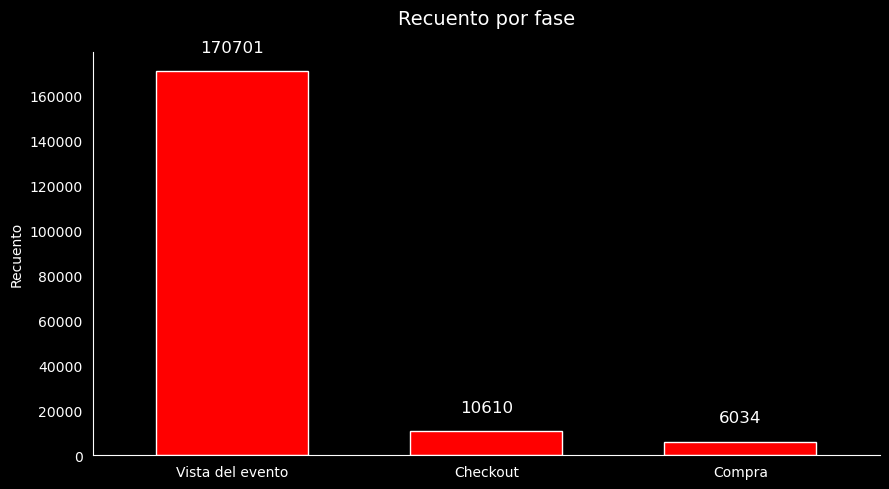

In [12]:
import matplotlib.pyplot as plt

conteo = df_funnel[['view_time', 'checkout_time', 'purchase_time']].count()

plt.figure(figsize=(9, 5), facecolor='black')
ax = conteo.plot(kind='bar', color=['red', 'red', 'red'], edgecolor='white', width=0.6)

plt.title('Recuento por fase', color='white', fontsize=14, pad=20)
plt.ylabel('Recuento', color='white')
plt.xticks(ticks=[0, 1, 2], labels=['Vista del evento', 'Checkout', 'Compra'], rotation=0, color='white')
plt.yticks(color='white')

# Añadir etiquetas encima de las barras
for i, v in enumerate(conteo):
    ax.text(i, v + max(conteo)*0.05, str(v), color='white', ha='center', fontsize=12)

# Configurar color de fondo y bordes
ax.set_facecolor('black')
ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()




170 701 visitas, solo 10 610 usuarios inician el proceso de pago y apenas 6034 completan la compra:   
El funnel pierde usuarios progresivamente, **con fuerte caída entre la visualización y la compra.**

**El drop-off en esta fase 93,78%.**     

Esto significa que casi el 94 % de los usuarios que ven el producto o el sitio web ni siquiera llegan a iniciar el proceso de pago.    

Nota:     
Mientras que el paso de Checkout a Purchase tiene una tasa de pérdida del 43,13 % , la brecha inicial entre la visualización y el inicio del pago es el punto crítico en el que se pierde la gran mayoría del volumen de usuarios.

### Device type

In [48]:
df_funnel

,user_id,event_id,view_time,device_type,country,checkout_time,purchase_time,ticket_price,discount_applied,genre,ticket_base_price
0,2328,68,2026-01-01 23:41:00,mobile,DE,NaT,NaT,NaN,NaN,Festival,47.89
1,9340,58,2026-01-01 22:09:00,mobile,ES,2026-01-01 22:32:00,NaT,NaN,NaN,Festival,47.65
2,2812,58,2026-01-01 13:36:00,mobile,DE,NaT,NaT,NaN,NaN,Festival,47.65
3,11412,95,2026-01-01 20:20:00,mobile,UK,NaT,NaT,NaN,NaN,Urban,17.68
4,2386,103,2026-01-01 19:02:00,mobile,ES,NaT,NaT,NaN,NaN,Festival,38.58
...,...,...,...,...,...,...,...,...,...,...,...
170696,9665,86,2026-03-02 10:44:00,mobile,ES,NaT,NaT,NaN,NaN,Live Concert,29.58
170697,7932,53,2026-03-01 19:41:00,mobile,ES,NaT,NaT,NaN,NaN,Urban,28.06
170698,11900,117,2026-03-01 13:36:00,mobile,IT,NaT,NaT,NaN,NaN,Live Concert,19.16
170699,19276,58,2026-03-02 06:47:00,mobile,FR,NaT,NaT,NaN,NaN,Festival,47.65


In [50]:
df_funnel['Tiempo'] = pd.cut(
    df_funnel['view_time'],
    bins=2,
    labels=['a_30', 'b_30']
)


In [52]:
df_funnel

,user_id,event_id,view_time,device_type,country,checkout_time,purchase_time,ticket_price,discount_applied,genre,ticket_base_price,Tiempo
0,2328,68,2026-01-01 23:41:00,mobile,DE,NaT,NaT,NaN,NaN,Festival,47.89,a_30
1,9340,58,2026-01-01 22:09:00,mobile,ES,2026-01-01 22:32:00,NaT,NaN,NaN,Festival,47.65,a_30
2,2812,58,2026-01-01 13:36:00,mobile,DE,NaT,NaT,NaN,NaN,Festival,47.65,a_30
3,11412,95,2026-01-01 20:20:00,mobile,UK,NaT,NaT,NaN,NaN,Urban,17.68,a_30
4,2386,103,2026-01-01 19:02:00,mobile,ES,NaT,NaT,NaN,NaN,Festival,38.58,a_30
...,...,...,...,...,...,...,...,...,...,...,...,...
170696,9665,86,2026-03-02 10:44:00,mobile,ES,NaT,NaT,NaN,NaN,Live Concert,29.58,b_30
170697,7932,53,2026-03-01 19:41:00,mobile,ES,NaT,NaT,NaN,NaN,Urban,28.06,b_30
170698,11900,117,2026-03-01 13:36:00,mobile,IT,NaT,NaT,NaN,NaN,Live Concert,19.16,b_30
170699,19276,58,2026-03-02 06:47:00,mobile,FR,NaT,NaT,NaN,NaN,Festival,47.65,b_30


In [54]:
total_records = len(df_funnel)
grouped_counts = df_funnel.groupby(['Tiempo', 'device_type']).size()

print(total_records)
print(grouped_counts)

170701
Tiempo  device_type
a_30    desktop        22523
        mobile         52467
b_30    desktop        28670
        mobile         67041
dtype: int64


El 70% usa la app

In [57]:
subset_dev = df_funnel[['user_id', 'event_id', 'view_time', 'device_type', 'checkout_time', 'purchase_time', 'Tiempo']]
subset_dev.head()

,user_id,event_id,view_time,device_type,checkout_time,purchase_time,Tiempo
0,2328,68,2026-01-01 23:41:00,mobile,NaT,NaT,a_30
1,9340,58,2026-01-01 22:09:00,mobile,2026-01-01 22:32:00,NaT,a_30
2,2812,58,2026-01-01 13:36:00,mobile,NaT,NaT,a_30
3,11412,95,2026-01-01 20:20:00,mobile,NaT,NaT,a_30
4,2386,103,2026-01-01 19:02:00,mobile,NaT,NaT,a_30


In [59]:
results = subset_dev.groupby(['Tiempo', 'device_type']).agg(
    total_users=('user_id', 'count'),
    checkout_valid=('checkout_time', 'count'),
    checkout_null=('checkout_time', lambda x: x.isnull().sum()),
    purchase_valid=('purchase_time', 'count'),
    purchase_null=('purchase_time', lambda x: x.isnull().sum())
).reset_index()

results

,Tiempo,device_type,total_users,checkout_valid,checkout_null,purchase_valid,purchase_null
0,a_30,desktop,22523,1412,21111,976,21547
1,a_30,mobile,52467,3364,49103,2050,50417
2,b_30,desktop,28670,1759,26911,1047,27623
3,b_30,mobile,67041,4075,62966,1961,65080


In [61]:
results['% checkout'] = (results['checkout_valid'] / results['total_users']) * 100
results['conversion_rate'] = (results['purchase_valid'] / results['total_users']) * 100

results_final = results[['Tiempo', 'device_type', '% checkout', 'conversion_rate', 'total_users']]
results_final


,Tiempo,device_type,% checkout,conversion_rate,total_users
0,a_30,desktop,6.269147,4.333348,22523
1,a_30,mobile,6.411649,3.907218,52467
2,b_30,desktop,6.135333,3.651901,28670
3,b_30,mobile,6.078370,2.925076,67041


Posibles motivos realistas:   
- UX App

### Country

In [65]:
df_funnel

,user_id,event_id,view_time,device_type,country,checkout_time,purchase_time,ticket_price,discount_applied,genre,ticket_base_price,Tiempo
0,2328,68,2026-01-01 23:41:00,mobile,DE,NaT,NaT,NaN,NaN,Festival,47.89,a_30
1,9340,58,2026-01-01 22:09:00,mobile,ES,2026-01-01 22:32:00,NaT,NaN,NaN,Festival,47.65,a_30
2,2812,58,2026-01-01 13:36:00,mobile,DE,NaT,NaT,NaN,NaN,Festival,47.65,a_30
3,11412,95,2026-01-01 20:20:00,mobile,UK,NaT,NaT,NaN,NaN,Urban,17.68,a_30
4,2386,103,2026-01-01 19:02:00,mobile,ES,NaT,NaT,NaN,NaN,Festival,38.58,a_30
...,...,...,...,...,...,...,...,...,...,...,...,...
170696,9665,86,2026-03-02 10:44:00,mobile,ES,NaT,NaT,NaN,NaN,Live Concert,29.58,b_30
170697,7932,53,2026-03-01 19:41:00,mobile,ES,NaT,NaT,NaN,NaN,Urban,28.06,b_30
170698,11900,117,2026-03-01 13:36:00,mobile,IT,NaT,NaT,NaN,NaN,Live Concert,19.16,b_30
170699,19276,58,2026-03-02 06:47:00,mobile,FR,NaT,NaT,NaN,NaN,Festival,47.65,b_30


In [67]:
# 1) Contar los "user_id", agrupados por 'country' y 'Tiempo'
user_counts = df_funnel.groupby(['country', 'Tiempo'])['user_id'].count().rename('total_users').reset_index()

# 2) Contar el número de 'purchase_time' válidos (no nulos) y no válidos (nulos), agrupados por 'country' y 'Tiempo'
purchase_counts = (
    df_funnel.groupby(['country', 'Tiempo'])['purchase_time']
    .agg(['count', 'size', lambda x: x.notna().sum(), lambda x: x.isna().sum()])
    .rename(columns={'<lambda_0>': 'valid', '<lambda_1>': 'invalid'})
    .reset_index()
)

# Unir los resultados de los conteos de usuarios y compras
result_df = pd.merge(user_counts, purchase_counts[['country', 'Tiempo', 'valid', 'invalid']], on=['country', 'Tiempo'])

# 3) Calcular el porcentaje de 'purchase_time' válidos y no válidos sobre el total de "user_id"
result_df['%_valid_purchase'] = (result_df['valid'] / result_df['total_users']) * 100
result_df['%_invalid_purchase'] = (result_df['invalid'] / result_df['total_users']) * 100

# 4) Calcular la "conversion_rate": (número de 'purchase_time' válidos / número total de "user_id") *100
result_df['conversion_rate'] = (result_df['valid'] / result_df['total_users']) * 100
result_df


,country,Tiempo,total_users,valid,invalid,%_valid_purchase,%_invalid_purchase,conversion_rate
0,DE,a_30,11412,480,10932,4.206099,95.793901,4.206099
1,DE,b_30,14432,458,13974,3.173503,96.826497,3.173503
2,ES,a_30,33618,1345,32273,4.000833,95.999167,4.000833
3,ES,b_30,43254,1373,41881,3.174273,96.825727,3.174273
4,FR,a_30,11212,454,10758,4.049233,95.950767,4.049233
5,FR,b_30,14327,461,13866,3.217701,96.782299,3.217701
6,IT,a_30,11160,436,10724,3.906810,96.093190,3.906810
7,IT,b_30,14217,428,13789,3.010480,96.989520,3.010480
8,UK,a_30,7588,311,7277,4.098577,95.901423,4.098577
9,UK,b_30,9481,288,9193,3.037654,96.962346,3.037654


Descenso de conversion general en todos los países

## checkout_time y purchase_time

In [71]:
df_funnel.head()

,user_id,event_id,view_time,device_type,country,checkout_time,purchase_time,ticket_price,discount_applied,genre,ticket_base_price,Tiempo
0,2328,68,2026-01-01 23:41:00,mobile,DE,NaT,NaT,NaN,NaN,Festival,47.89,a_30
1,9340,58,2026-01-01 22:09:00,mobile,ES,2026-01-01 22:32:00,NaT,NaN,NaN,Festival,47.65,a_30
2,2812,58,2026-01-01 13:36:00,mobile,DE,NaT,NaT,NaN,NaN,Festival,47.65,a_30
3,11412,95,2026-01-01 20:20:00,mobile,UK,NaT,NaT,NaN,NaN,Urban,17.68,a_30
4,2386,103,2026-01-01 19:02:00,mobile,ES,NaT,NaT,NaN,NaN,Festival,38.58,a_30


In [73]:
df_funnel = df_funnel.copy()


df_funnel[["checkout_time", "purchase_time"]] = df_funnel[["checkout_time", "purchase_time"]].apply(pd.to_datetime)
df_funnel["diff_minutes"] = (df_funnel["purchase_time"] - df_funnel["checkout_time"]).dt.total_seconds() / 60

In [75]:
df_funnel

,user_id,event_id,view_time,device_type,country,checkout_time,purchase_time,ticket_price,discount_applied,genre,ticket_base_price,Tiempo,diff_minutes
0,2328,68,2026-01-01 23:41:00,mobile,DE,NaT,NaT,NaN,NaN,Festival,47.89,a_30,NaN
1,9340,58,2026-01-01 22:09:00,mobile,ES,2026-01-01 22:32:00,NaT,NaN,NaN,Festival,47.65,a_30,NaN
2,2812,58,2026-01-01 13:36:00,mobile,DE,NaT,NaT,NaN,NaN,Festival,47.65,a_30,NaN
3,11412,95,2026-01-01 20:20:00,mobile,UK,NaT,NaT,NaN,NaN,Urban,17.68,a_30,NaN
4,2386,103,2026-01-01 19:02:00,mobile,ES,NaT,NaT,NaN,NaN,Festival,38.58,a_30,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
170696,9665,86,2026-03-02 10:44:00,mobile,ES,NaT,NaT,NaN,NaN,Live Concert,29.58,b_30,NaN
170697,7932,53,2026-03-01 19:41:00,mobile,ES,NaT,NaT,NaN,NaN,Urban,28.06,b_30,NaN
170698,11900,117,2026-03-01 13:36:00,mobile,IT,NaT,NaT,NaN,NaN,Live Concert,19.16,b_30,NaN
170699,19276,58,2026-03-02 06:47:00,mobile,FR,NaT,NaT,NaN,NaN,Festival,47.65,b_30,NaN


In [77]:
conteo = df_funnel["diff_minutes"].value_counts().sort_index()
print(conteo)

diff_minutes
1.0        185
2.0        207
3.0        210
4.0        227
5.0        278
6.0        330
7.0        304
8.0        283
9.0        332
10.0       286
11.0       280
12.0       287
13.0       311
14.0       295
15.0        86
16.0        76
17.0        90
18.0        91
19.0        71
20.0       106
21.0        88
22.0        90
23.0        90
24.0        93
25.0        83
26.0        94
27.0        95
28.0        80
29.0        92
30.0        94
31.0        85
32.0        93
33.0        80
34.0        83
35.0        94
36.0        94
37.0        74
38.0        91
39.0        97
14472.0      1
15710.0      1
22599.0      1
22979.0      1
27085.0      1
27742.0      1
32300.0      1
52388.0      1
73767.0      1
Name: count, dtype: int64


In [79]:
df_funnel_sorted = df_funnel.sort_values(by='diff_minutes', ascending=False)
df_funnel_sorted.head(10)

,user_id,event_id,view_time,device_type,country,checkout_time,purchase_time,ticket_price,discount_applied,genre,ticket_base_price,Tiempo,diff_minutes
16720,2310,72,2026-01-07 18:18:00,mobile,UK,2026-01-07 18:39:00,2026-02-28 00:06:00,14.82,10.0,DJ Set,24.82,a_30,73767.0
5092,11718,58,2026-01-03 20:05:00,desktop,FR,2026-01-03 20:27:00,2026-02-09 05:35:00,47.65,0.0,Festival,47.65,a_30,52388.0
60138,8730,56,2026-01-25 20:00:00,mobile,DE,2026-01-25 20:14:00,2026-02-17 06:34:00,38.29,0.0,Techno,38.29,a_30,32300.0
87164,12640,33,2026-02-04 03:30:00,mobile,FR,2026-02-04 03:51:00,2026-02-23 10:13:00,19.71,0.0,Urban,19.71,b_30,27742.0
38108,16252,70,2026-01-17 07:28:00,desktop,ES,2026-01-17 07:51:00,2026-02-05 03:16:00,26.81,0.0,Live Concert,26.81,a_30,27085.0
31838,10113,16,2026-01-14 09:13:00,desktop,ES,2026-01-14 09:21:00,2026-01-30 08:20:00,19.94,0.0,Live Concert,19.94,a_30,22979.0
87806,14499,21,2026-02-05 07:33:00,mobile,DE,2026-02-05 08:00:00,2026-02-21 00:39:00,43.19,0.0,Techno,43.19,b_30,22599.0
88680,8893,50,2026-02-04 20:54:00,mobile,DE,2026-02-04 21:13:00,2026-02-15 19:03:00,26.62,0.0,House,26.62,b_30,15710.0
22491,2811,14,2026-01-11 00:46:00,desktop,ES,2026-01-11 00:55:00,2026-01-21 02:07:00,31.20,0.0,Festival,31.20,a_30,14472.0
117029,12500,24,2026-02-14 03:15:00,mobile,UK,2026-02-14 03:35:00,2026-02-14 04:14:00,22.28,0.0,Clubbing,22.28,b_30,39.0


In [81]:
df_funnel[df_funnel['user_id'] == 2310].sort_values(by='diff_minutes', ascending=False)

,user_id,event_id,view_time,device_type,country,checkout_time,purchase_time,ticket_price,discount_applied,genre,ticket_base_price,Tiempo,diff_minutes
16720,2310,72,2026-01-07 18:18:00,mobile,UK,2026-01-07 18:39:00,2026-02-28 00:06:00,14.82,10.0,DJ Set,24.82,a_30,73767.0
16719,2310,72,2026-01-07 18:18:00,mobile,UK,2026-02-27 23:36:00,2026-02-28 00:06:00,14.82,10.0,DJ Set,24.82,a_30,30.0
161632,2310,72,2026-02-27 23:08:00,mobile,ES,2026-02-27 23:36:00,2026-02-28 00:06:00,14.82,10.0,DJ Set,24.82,b_30,30.0
17956,2310,69,2026-01-08 17:46:00,mobile,FR,NaT,NaT,NaN,NaN,Urban,21.77,a_30,NaN
62447,2310,17,2026-01-25 22:47:00,mobile,FR,NaT,NaT,NaN,NaN,Urban,26.57,a_30,NaN
87328,2310,116,2026-02-03 22:19:00,desktop,ES,NaT,NaT,NaN,NaN,Clubbing,24.83,b_30,NaN
109067,2310,71,2026-02-11 00:45:00,mobile,ES,NaT,NaT,NaN,NaN,DJ Set,32.69,b_30,NaN
117847,2310,55,2026-02-14 04:53:00,mobile,IT,NaT,NaT,NaN,NaN,DJ Set,29.66,b_30,NaN
119089,2310,49,2026-02-14 07:12:00,desktop,IT,NaT,NaT,NaN,NaN,Electronic,30.90,b_30,NaN
119356,2310,33,2026-02-14 03:56:00,mobile,ES,NaT,NaT,NaN,NaN,Urban,19.71,b_30,NaN


Los valores fuera de escala deberán eliminarse para continuar con el análisis, pero indican un problema de error.  
**Informar del problema al equipo de desarrollo.**

In [84]:
df_funnel = df_funnel[df_funnel['diff_minutes'] <= 50]

In [86]:
conteggio = df_funnel["diff_minutes"].value_counts().sort_index()
conteggio

diff_minutes
1.0     185
2.0     207
3.0     210
4.0     227
5.0     278
6.0     330
7.0     304
8.0     283
9.0     332
10.0    286
11.0    280
12.0    287
13.0    311
14.0    295
15.0     86
16.0     76
17.0     90
18.0     91
19.0     71
20.0    106
21.0     88
22.0     90
23.0     90
24.0     93
25.0     83
26.0     94
27.0     95
28.0     80
29.0     92
30.0     94
31.0     85
32.0     93
33.0     80
34.0     83
35.0     94
36.0     94
37.0     74
38.0     91
39.0     97
Name: count, dtype: int64

In [88]:
df_funnel.head()

,user_id,event_id,view_time,device_type,country,checkout_time,purchase_time,ticket_price,discount_applied,genre,ticket_base_price,Tiempo,diff_minutes
48,19224,79,2026-01-02 02:05:00,mobile,ES,2026-01-02 02:28:00,2026-01-02 02:38:00,15.06,0.0,Clubbing,15.06,a_30,10.0
87,4805,46,2026-01-02 00:27:00,desktop,ES,2026-01-02 00:34:00,2026-01-02 00:38:00,22.70,0.0,House,22.70,a_30,4.0
124,17845,21,2026-01-01 21:33:00,mobile,ES,2026-01-01 21:46:00,2026-01-01 21:58:00,43.19,0.0,Techno,43.19,a_30,12.0
136,18379,14,2026-01-02 05:48:00,mobile,ES,2026-01-02 05:56:00,2026-01-02 06:03:00,31.20,0.0,Festival,31.20,a_30,7.0
173,11486,37,2026-01-02 08:37:00,desktop,ES,2026-01-18 10:42:00,2026-01-18 10:46:00,10.20,5.0,Urban,15.20,a_30,4.0


In [90]:
df_funnel_1 = df_funnel.copy()
df_funnel_1['view_time'] = df_funnel_1['view_time'].dt.strftime('%m-%d')
df_funnel_1 = df_funnel_1[['view_time', 'diff_minutes']]
df_funnel_1

,view_time,diff_minutes
48,01-02,10.0
87,01-02,4.0
124,01-01,12.0
136,01-02,7.0
173,01-02,4.0
...,...,...
170590,03-01,20.0
170594,03-01,35.0
170604,03-01,30.0
170638,03-02,35.0


In [92]:
df_funnel_1.groupby('view_time')['diff_minutes'].mean()

view_time
01-01     8.520000
01-02     7.455556
01-03     8.063158
01-04     7.483871
01-05     7.614679
           ...    
02-26    22.320000
02-27    22.161616
02-28    22.744681
03-01    21.654206
03-02    24.439024
Name: diff_minutes, Length: 61, dtype: float64

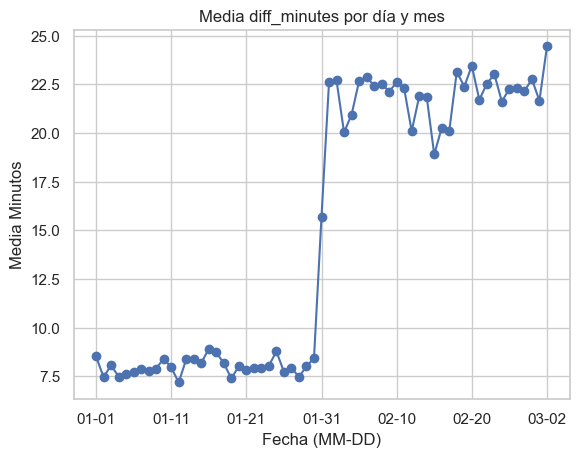

In [94]:
import matplotlib.pyplot as plt

df_grouped = df_funnel_1.groupby('view_time')['diff_minutes'].mean()

df_grouped.plot(kind='line', marker='o')
plt.title('Media diff_minutes por día y mes')
plt.xlabel('Fecha (MM-DD)')
plt.ylabel('Media Minutos')
plt.show()

**Aumento significativo del tiempo medio de checkoutde febrero**

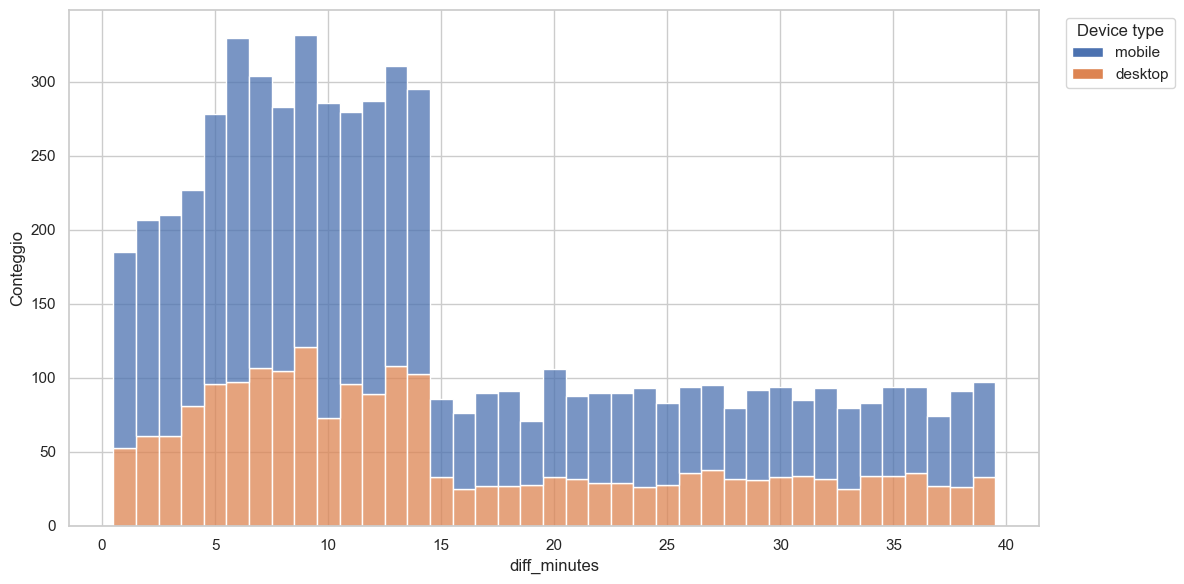

In [104]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

ax = sns.histplot(
    data=df_funnel,
    x='diff_minutes',
    hue='device_type',
    multiple='stack',
    bins=range(int(df_funnel['diff_minutes'].min()), int(df_funnel['diff_minutes'].max()) + 2),
    discrete=True,
    palette='deep'          
)


handles, labels = ax.get_legend_handles_labels()

if handles:                  
    ax.legend(handles, labels, title='Device type',
              bbox_to_anchor=(1.02, 1), loc='upper left')
else:

    unique_devices = df_funnel['device_type'].dropna().unique()
    if len(unique_devices) > 0:
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor=sns.color_palette('deep', len(unique_devices))[i],
                                 label=dev) for i, dev in enumerate(unique_devices)]
        ax.legend(handles=legend_elements, title='Device type',
                  bbox_to_anchor=(1.02, 1), loc='upper left')

plt.xlabel('diff_minutes')
plt.ylabel('Conteggio')
plt.tight_layout()
plt.show()

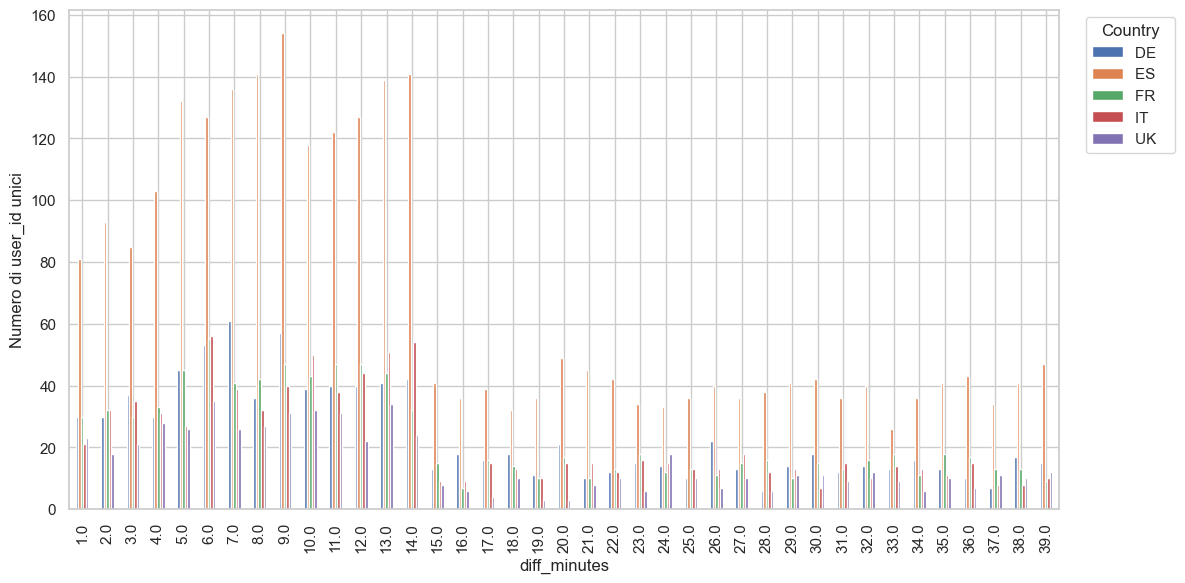

In [106]:
df_funnel.groupby(['diff_minutes', 'country'])['user_id'].nunique().reset_index(name='count') \
    .pivot(index='diff_minutes', columns='country', values='count') \
    .fillna(0) \
    .plot(kind='bar', stacked=False, figsize=(12, 6))

plt.xlabel('diff_minutes')
plt.ylabel('Numero di user_id unici')
plt.legend(title='Country', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

 El dispositivo o el país no tienen relación con el tiempo transcurrido entre el momento del pago y la compra.

In [110]:
df_funnel_2 = df_funnel.copy()
df_funnel_2['view_time'] = df_funnel_2['view_time'].dt.strftime('%m-%d')
df_funnel_2 = df_funnel_2[['view_time', 'device_type','diff_minutes']]
df_funnel_2

,view_time,device_type,diff_minutes
48,01-02,mobile,10.0
87,01-02,desktop,4.0
124,01-01,mobile,12.0
136,01-02,mobile,7.0
173,01-02,desktop,4.0
...,...,...,...
170590,03-01,mobile,20.0
170594,03-01,mobile,35.0
170604,03-01,mobile,30.0
170638,03-02,mobile,35.0


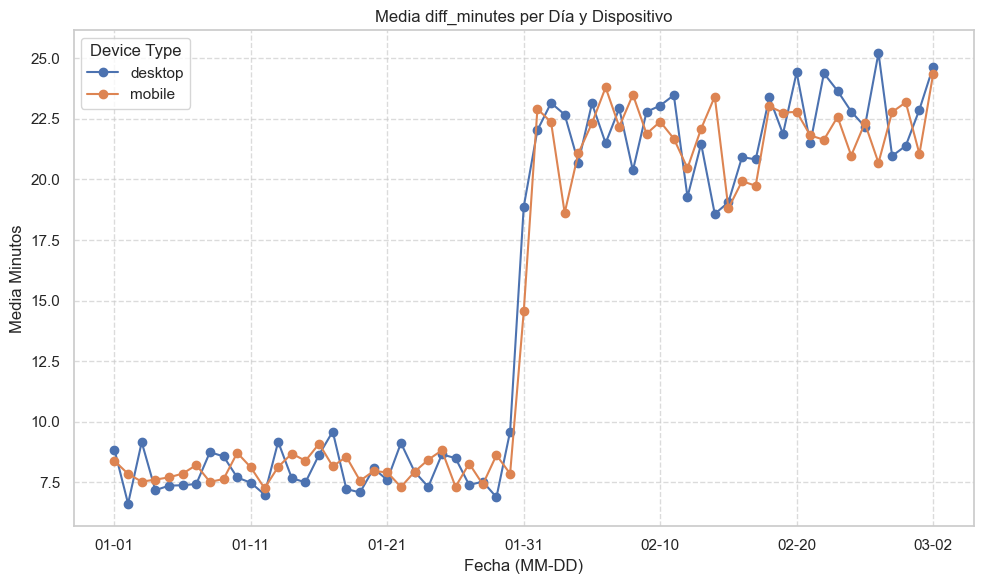

In [112]:
import matplotlib.pyplot as plt

# Raggruppa per tempo e dispositivo, calcola la media e trasforma device_type in colonne
df_plot = df_funnel_2.groupby(['view_time', 'device_type'])['diff_minutes'].mean().unstack()

# Crea il grafico
df_plot.plot(kind='line', marker='o', figsize=(10, 6))

plt.title('Media diff_minutes per Día y Dispositivo')
plt.xlabel('Fecha (MM-DD)')
plt.ylabel('Media Minutos')
plt.legend(title='Device Type')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig('linechart_device.png')

**Inicio febrero**

In [115]:
df_funnel_3 = df_funnel.copy()
df_funnel_3['view_time'] = df_funnel_3['view_time'].dt.strftime('%m-%d')
df_funnel_3 = df_funnel_3[['view_time', 'ticket_price','diff_minutes']]
df_funnel_3

,view_time,ticket_price,diff_minutes
48,01-02,15.06,10.0
87,01-02,22.70,4.0
124,01-01,43.19,12.0
136,01-02,31.20,7.0
173,01-02,10.20,4.0
...,...,...,...
170590,03-01,38.19,20.0
170594,03-01,15.06,35.0
170604,03-01,51.02,30.0
170638,03-02,23.36,35.0


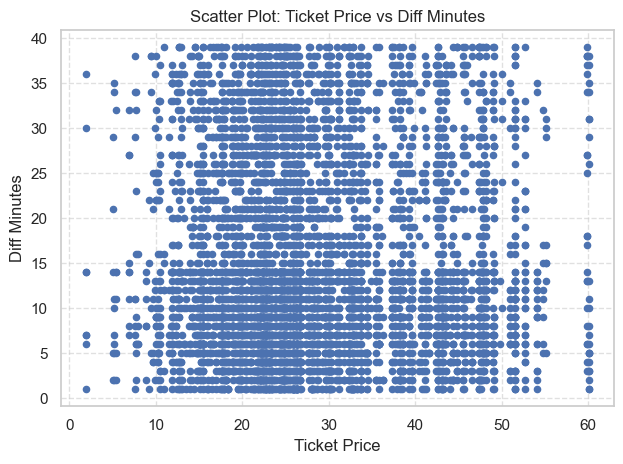

In [117]:
import matplotlib.pyplot as plt

df_funnel_3.plot(kind='scatter', x='ticket_price', y='diff_minutes')

plt.title('Scatter Plot: Ticket Price vs Diff Minutes')
plt.xlabel('Ticket Price')
plt.ylabel('Diff Minutes')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
#plt.savefig('scatterplot_price_minutes.png')

No existe correlación entre el momento de la compra y el precio.

## Precio Ticket 

In [122]:
funnel = "SELECT * FROM event_funnel"
df_funnel = pd.read_sql(funnel, engine)
df_funnel.head()

,user_id,event_id,view_time,device_type,country,checkout_time,purchase_time,ticket_price,discount_applied,genre,ticket_base_price
0,2328,68,2026-01-01 23:41:00,mobile,DE,NaT,NaT,NaN,NaN,Festival,47.89
1,9340,58,2026-01-01 22:09:00,mobile,ES,2026-01-01 22:32:00,NaT,NaN,NaN,Festival,47.65
2,2812,58,2026-01-01 13:36:00,mobile,DE,NaT,NaT,NaN,NaN,Festival,47.65
3,11412,95,2026-01-01 20:20:00,mobile,UK,NaT,NaT,NaN,NaN,Urban,17.68
4,2386,103,2026-01-01 19:02:00,mobile,ES,NaT,NaT,NaN,NaN,Festival,38.58


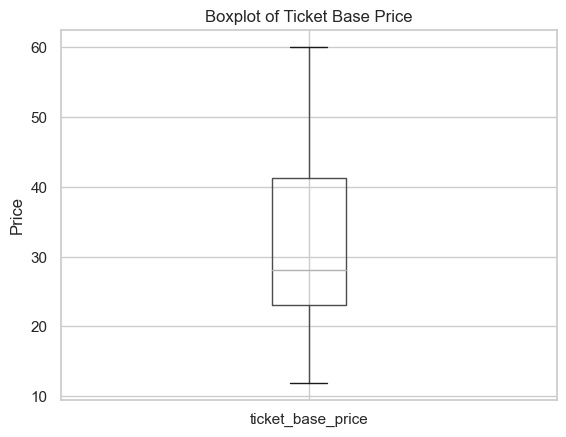

In [124]:
import matplotlib.pyplot as plt

df_funnel.boxplot(column='ticket_base_price')
plt.title('Boxplot of Ticket Base Price')
plt.ylabel('Price')
plt.show()

In [126]:
print(df_funnel['ticket_base_price'].describe()[['min', '25%', '50%', '75%', 'max']])

min    11.90
25%    23.07
50%    28.06
75%    41.24
max    60.09
Name: ticket_base_price, dtype: float64


In [128]:
df = df_funnel.copy()

df['range_precio'] = pd.cut(
    df['ticket_base_price'],
    bins=[10, 20, 30, 40, 50, float('inf')],
    labels=['10-20', '20-30', '30-40', '40-50', '>50'],
    right=False,
    include_lowest=True
)

# Correzione per avere esattamente le categorie richieste (sostituisce >50 con >60 se preferisci)
df['range_precio'] = df['range_precio'].replace('>50', '>60')

In [130]:
import numpy as np
df['view_time'] = pd.to_datetime(df['view_time'])

midpoint = df['view_time'].median()
df['Tiempo'] = np.where(df['view_time'] <= midpoint, '30_d', '60_d')

In [132]:
df_summary = df.groupby(['range_precio', 'Tiempo']).agg(
    total_users=('user_id', 'count'),
    checkout_valid=('checkout_time', 'count'),
    checkout_null=('checkout_time', lambda x: x.isnull().sum()),
    purchase_valid=('purchase_time', 'count'),
    purchase_null=('purchase_time', lambda x: x.isnull().sum())
)

df_summary

total_users  checkout_valid  checkout_null  \
range_precio Tiempo                                               
10-20        30_d           9263             593           8670   
             60_d           9406             619           8787   
20-30        30_d          38153            2395          35758   
             60_d          37433            2241          35192   
30-40        30_d          15281             932          14349   
             60_d          15734            1025          14709   
40-50        30_d          17053            1128          15925   
             60_d          17082            1012          16070   
>60          30_d           5601             343           5258   
             60_d           5695             322           5373   

                     purchase_valid  purchase_null  
range_precio Tiempo                                 
10-20        30_d               384           8879  
             60_d               361           9045  
20-30        30_d              1602          36551  
             60_d              1220          36213  
30-40        30_d               621          14660  
             60_d               549          15185  
40-50        30_d               572          16481  
             60_d               425          16657  
>60          30_d               163           5438  
             60_d               137           5558

In [134]:
df_summary['conversion_rate'] = (df_summary['purchase_valid'] / df_summary['total_users']) * 100

df_summary

total_users  checkout_valid  checkout_null  \
range_precio Tiempo                                               
10-20        30_d           9263             593           8670   
             60_d           9406             619           8787   
20-30        30_d          38153            2395          35758   
             60_d          37433            2241          35192   
30-40        30_d          15281             932          14349   
             60_d          15734            1025          14709   
40-50        30_d          17053            1128          15925   
             60_d          17082            1012          16070   
>60          30_d           5601             343           5258   
             60_d           5695             322           5373   

                     purchase_valid  purchase_null  conversion_rate  
range_precio Tiempo                                                  
10-20        30_d               384           8879         4.145525  
             60_d               361           9045         3.837976  
20-30        30_d              1602          36551         4.198883  
             60_d              1220          36213         3.259156  
30-40        30_d               621          14660         4.063870  
             60_d               549          15185         3.489259  
40-50        30_d               572          16481         3.354249  
             60_d               425          16657         2.487999  
>60          30_d               163           5438         2.910195  
             60_d               137           5558         2.405619

A precios más altos, disminuye la tasa de conversión (para cada rango).

In [137]:
df_summary2 = df.groupby(['range_precio', 'genre']).agg(
    total_users=('user_id', 'count'),
    checkout_valid=('checkout_time', 'count'),
    checkout_null=('checkout_time', lambda x: x.isnull().sum()),
    purchase_valid=('purchase_time', 'count'),
    purchase_null=('purchase_time', lambda x: x.isnull().sum())
)

df_summary2

total_users  checkout_valid  checkout_null  \
range_precio genre                                                      
10-20        Clubbing             7168             474         6694.0   
             DJ Set                  0               0            NaN   
             Electronic              0               0            NaN   
             Festival                0               0            NaN   
             House                2828             177         2651.0   
             Live Concert         2886             176         2710.0   
             Techno                  0               0            NaN   
             Urban                5787             385         5402.0   
20-30        Clubbing             8532             526         8006.0   
             DJ Set              11451             671        10780.0   
             Electronic              0               0            NaN   
             Festival                0               0            NaN   
             House               15564             888        14676.0   
             Live Concert        14384             936        13448.0   
             Techno                  0               0            NaN   
             Urban               25655            1615        24040.0   
30-40        Clubbing             4237             269         3968.0   
             DJ Set               2818             162         2656.0   
             Electronic           5621             370         5251.0   
             Festival             6958             443         6515.0   
             House                1453              86         1367.0   
             Live Concert         7076             435         6641.0   
             Techno               2852             192         2660.0   
             Urban                   0               0            NaN   
40-50        Clubbing                0               0            NaN   
             DJ Set                  0               0            NaN   
             Electronic          10017             594         9423.0   
             Festival            11325             742        10583.0   
             House                   0               0            NaN   
             Live Concert            0               0            NaN   
             Techno              12793             804        11989.0   
             Urban                   0               0            NaN   
>60          Clubbing                0               0            NaN   
             DJ Set                  0               0            NaN   
             Electronic           4301             253         4048.0   
             Festival             2782             171         2611.0   
             House                   0               0            NaN   
             Live Concert            0               0            NaN   
             Techno               4213             241         3972.0   
             Urban                   0               0            NaN   

                           purchase_valid  purchase_null  
range_precio genre                                        
10-20        Clubbing                 290         6878.0  
             DJ Set                     0            NaN  
             Electronic                 0            NaN  
             Festival                   0            NaN  
             House                    104         2724.0  
             Live Concert             107         2779.0  
             Techno                     0            NaN  
             Urban                    244         5543.0  
20-30        Clubbing                 341         8191.0  
             DJ Set                   422        11029.0  
             Electronic                 0            NaN  
             Festival                   0            NaN  
             House                    522        15042.0  
             Live Concert             540        13844.0  
             Tec

In [139]:
df_summary2 = df_summary2.dropna()

In [141]:
df_summary2

total_users  checkout_valid  checkout_null  \
range_precio genre                                                      
10-20        Clubbing             7168             474         6694.0   
             House                2828             177         2651.0   
             Live Concert         2886             176         2710.0   
             Urban                5787             385         5402.0   
20-30        Clubbing             8532             526         8006.0   
             DJ Set              11451             671        10780.0   
             House               15564             888        14676.0   
             Live Concert        14384             936        13448.0   
             Urban               25655            1615        24040.0   
30-40        Clubbing             4237             269         3968.0   
             DJ Set               2818             162         2656.0   
             Electronic           5621             370         5251.0   
             Festival             6958             443         6515.0   
             House                1453              86         1367.0   
             Live Concert         7076             435         6641.0   
             Techno               2852             192         2660.0   
40-50        Electronic          10017             594         9423.0   
             Festival            11325             742        10583.0   
             Techno              12793             804        11989.0   
>60          Electronic           4301             253         4048.0   
             Festival             2782             171         2611.0   
             Techno               4213             241         3972.0   

                           purchase_valid  purchase_null  
range_precio genre                                        
10-20        Clubbing                 290         6878.0  
             House                    104         2724.0  
             Live Concert             107         2779.0  
             Urban                    244         5543.0  
20-30        Clubbing                 341         8191.0  
             DJ Set                   422        11029.0  
             House                    522        15042.0  
             Live Concert             540        13844.0  
             Urban                    997        24658.0  
30-40        Clubbing                 159         4078.0  
             DJ Set                    92         2726.0  
             Electronic               220         5401.0  
             Festival                 259         6699.0  
             House                     50         1403.0  
             Live Concert             262         6814.0  
             Techno                   128         2724.0  
40-50        Electronic               267         9750.0  
             Festival                 339        10986.0  
             Techno                   391        12402.0  
>60          Electronic               102         4199.0  
             Festival                  83         2699.0  
             Techno                   115         4098.0

In [143]:
df_summary2 = df_summary2.copy()

df_summary2.loc[:, 'conversion_rate'] = (df_summary2['purchase_valid'] / df_summary2['total_users']) * 100

In [145]:
df_summary2.loc[:, 'conversion_rate'] = df_summary2['conversion_rate'].round(1)

In [147]:
df_summary2

total_users  checkout_valid  checkout_null  \
range_precio genre                                                      
10-20        Clubbing             7168             474         6694.0   
             House                2828             177         2651.0   
             Live Concert         2886             176         2710.0   
             Urban                5787             385         5402.0   
20-30        Clubbing             8532             526         8006.0   
             DJ Set              11451             671        10780.0   
             House               15564             888        14676.0   
             Live Concert        14384             936        13448.0   
             Urban               25655            1615        24040.0   
30-40        Clubbing             4237             269         3968.0   
             DJ Set               2818             162         2656.0   
             Electronic           5621             370         5251.0   
             Festival             6958             443         6515.0   
             House                1453              86         1367.0   
             Live Concert         7076             435         6641.0   
             Techno               2852             192         2660.0   
40-50        Electronic          10017             594         9423.0   
             Festival            11325             742        10583.0   
             Techno              12793             804        11989.0   
>60          Electronic           4301             253         4048.0   
             Festival             2782             171         2611.0   
             Techno               4213             241         3972.0   

                           purchase_valid  purchase_null  conversion_rate  
range_precio genre                                                         
10-20        Clubbing                 290         6878.0              4.0  
             House                    104         2724.0              3.7  
             Live Concert             107         2779.0              3.7  
             Urban                    244         5543.0              4.2  
20-30        Clubbing                 341         8191.0              4.0  
             DJ Set                   422        11029.0              3.7  
             House                    522        15042.0              3.4  
             Live Concert             540        13844.0              3.8  
             Urban                    997        24658.0              3.9  
30-40        Clubbing                 159         4078.0              3.8  
             DJ Set                    92         2726.0              3.3  
             Electronic               220         5401.0              3.9  
             Festival                 259         6699.0              3.7  
             House                     50         1403.0              3.4  
             Live Concert             262         6814.0              3.7  
             Techno                   128         2724.0              4.5  
40-50        Electronic               267         9750.0              2.7  
             Festival                 339        10986.0              3.0  
             Techno                   391        12402.0              3.1  
>60          Electronic               102         4199.0              2.4  
             Festival                  83         2699.0              3.0  
             Techno                   115         4098.0              2.7

 Los precios altos convierten menos, Eletronic y Techno bajan aún más la media.  
 Segmentación de marketing ineficaz

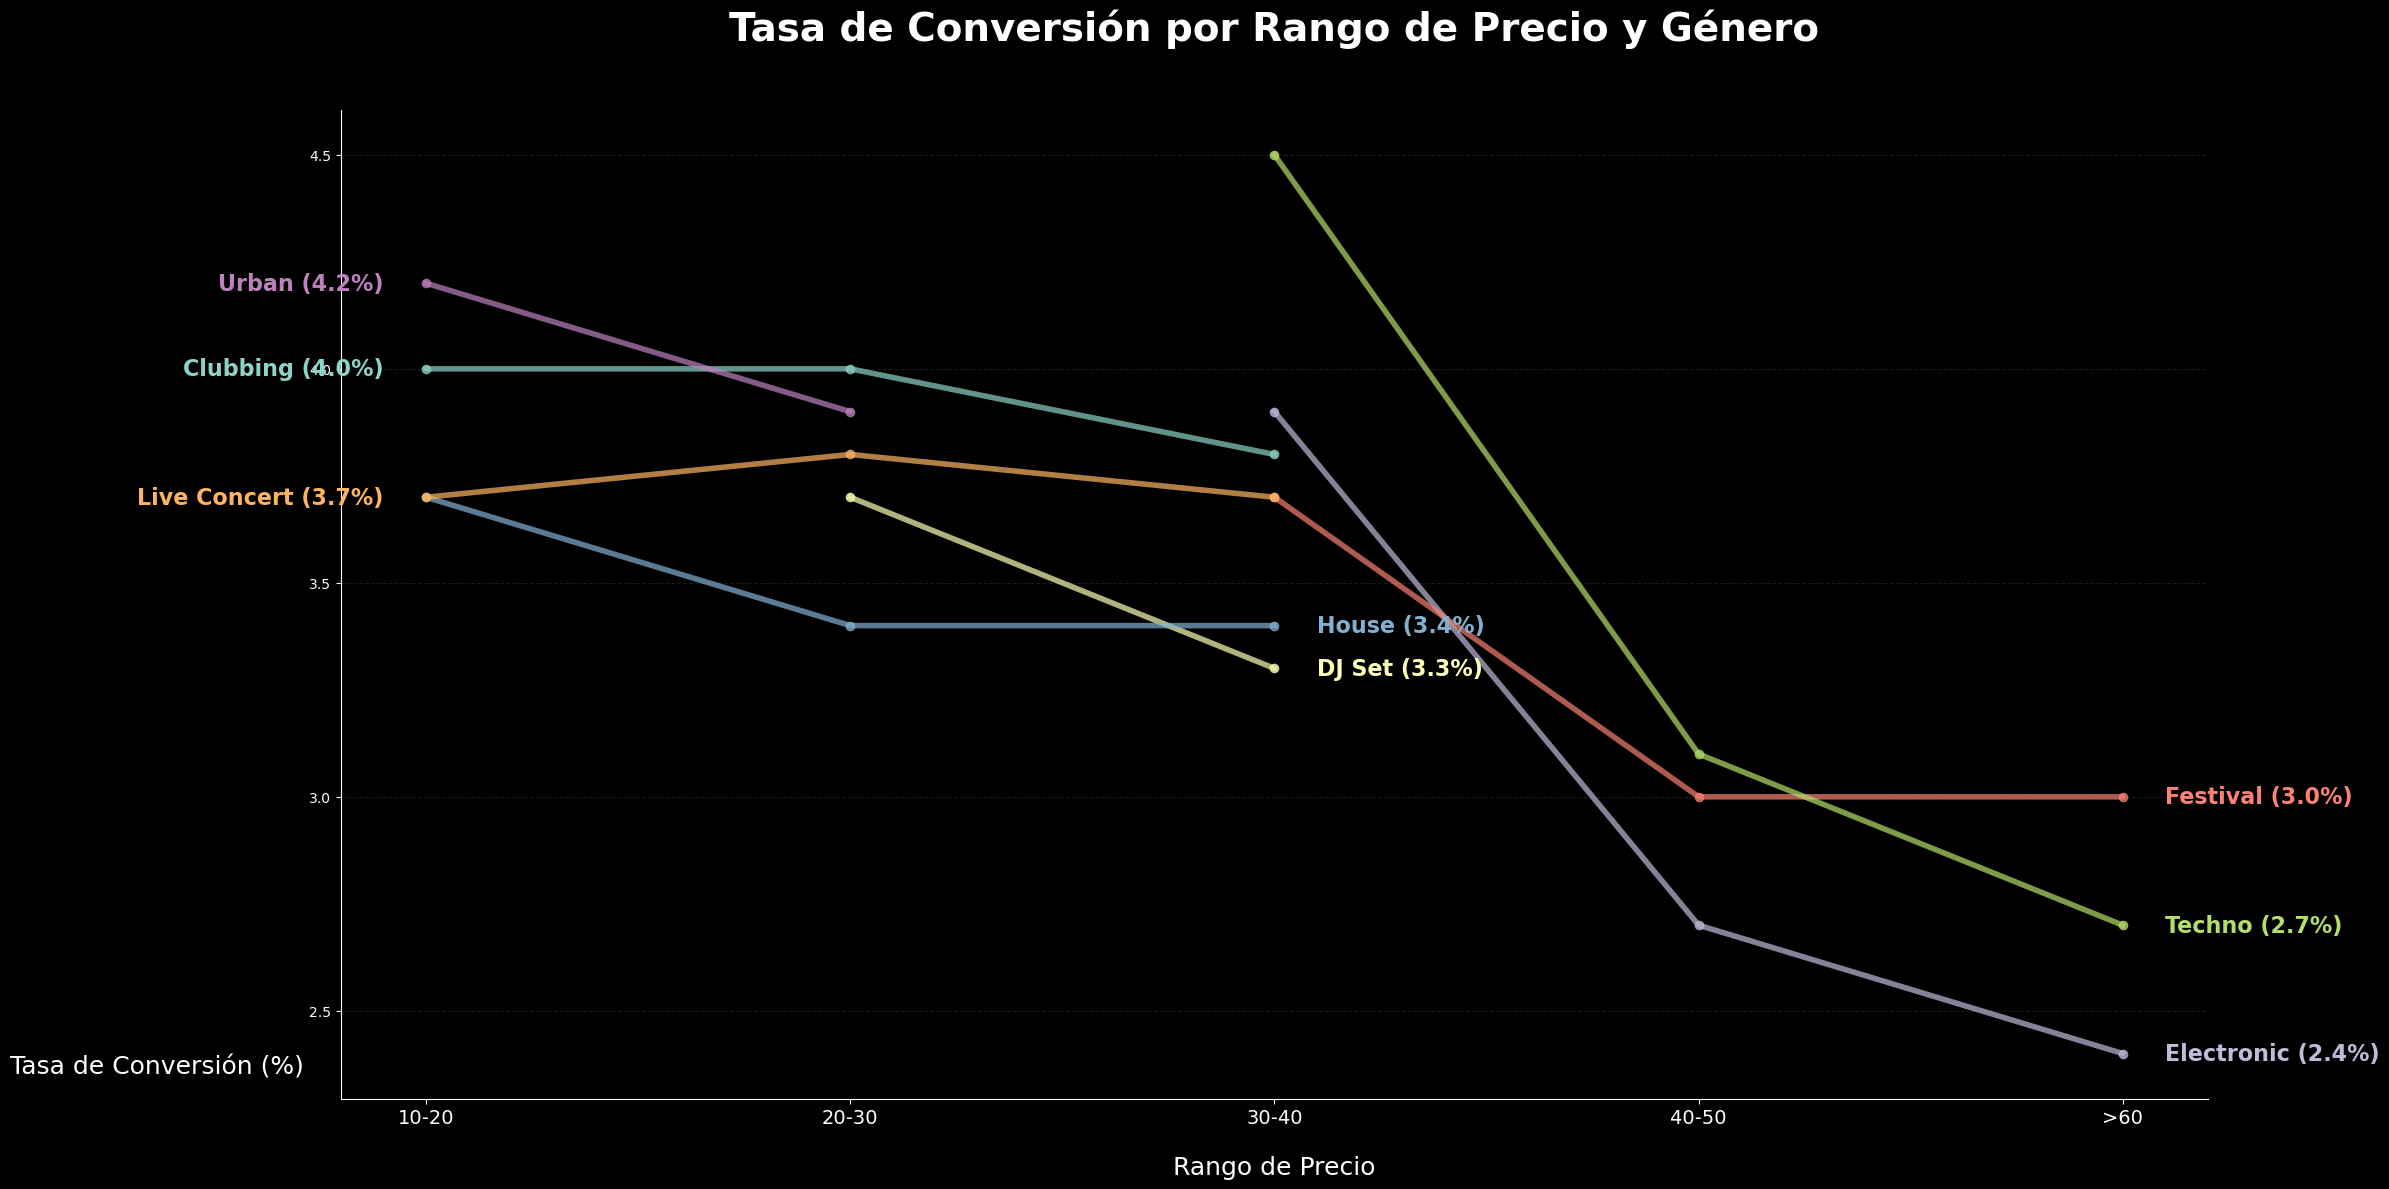

In [126]:
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import numpy as np

# Forzar el cierre de cualquier gráfico abierto previamente
plt.close('all')
plt.style.use('dark_background')

# Creación de la figura
fig, ax = plt.subplots(figsize=(24, 12))

# Preparación de datos
df_plot = df_summary2.pivot_table(
    index='range_precio',
    columns='genre',
    values='conversion_rate'
)

x_numeric = np.arange(len(df_plot.index))

# --- CONFIGURACIÓN ---
# Géneros que se posicionarán al INICIO de la línea
start_labels = [
    'Dj Set',
    'Live Concert',
    #'House',  # ← eliminado → ahora va al final de la línea
    'Urban',
    'Clubbing'
]

# Offsets personalizados
offsets = {
    'Clubbing': {'x': -0.1, 'y': 0.8},
    'Live Concert': {'x': -0.1, 'y': 0.4},
    'House': {'x': 0.1, 'y': -0.30},  # ← offset para final de línea (x positivo, y más bajo)
    # puedes añadir otros si es necesario
}

# --- Creación de líneas y etiquetas ---
for genre in df_plot.columns:

    y_raw = df_plot[genre].values
    mask = ~np.isnan(y_raw)
    x_clean = x_numeric[mask]
    y_clean = y_raw[mask]

    if len(y_clean) == 0:
        continue

    if len(y_clean) > 3:

        x_new = np.linspace(x_clean.min(), x_clean.max(), 300)
        spl = make_interp_spline(x_clean, y_clean, k=3)
        y_smooth = spl(x_new)

        # Dibujar línea gruesa suavizada
        line, = ax.plot(x_new, y_smooth, linewidth=7, alpha=0.85)
        color = line.get_color()

        # Offset por defecto (izquierda para inicio, derecha para final)
        default_off_x = -0.1 if genre in start_labels else 0.1
        off_x = offsets.get(genre, {}).get('x', default_off_x)
        off_y = offsets.get(genre, {}).get('y', 0.0)

        # Lógica de posicionamiento de etiqueta
        if genre in start_labels:
            # POSICIÓN AL INICIO
            label_text = f"{genre} ({y_clean[0]:.1f}%)"
            ax.text(
                x_clean[0] + off_x,
                y_clean[0] + off_y,
                label_text,
                color=color,
                fontweight='bold',
                ha='right',
                va='center',
                fontsize=16
            )
        else:
            # POSICIÓN AL FINAL
            label_text = f"{genre} ({y_clean[-1]:.1f}%)"
            ax.text(
                x_clean[-1] + off_x,
                y_clean[-1] + off_y,
                label_text,
                color=color,
                fontweight='bold',
                ha='left',
                va='center',
                fontsize=16
            )

    else:
        # Caso con pocos datos disponibles
        line, = ax.plot(x_clean, y_clean, marker='o', linewidth=4, alpha=0.7)
        color = line.get_color()

        if genre in start_labels:
            ax.text(
                x_clean[0] - 0.1,
                y_clean[0],
                f"{genre} ({y_clean[0]:.1f}%)",
                color=color,
                fontweight='bold',
                ha='right',
                va='center',
                fontsize=16
            )
        else:
            ax.text(
                x_clean[-1] + 0.1,
                y_clean[-1] + off_y,  # ← aplicar también offset en Y si existe
                f"{genre} ({y_clean[-1]:.1f}%)",
                color=color,
                fontweight='bold',
                ha='left',
                va='center',
                fontsize=16
            )

# --- Configuración de ejes ---
ax.set_xticks(x_numeric)
ax.set_xticklabels(df_plot.index, fontsize=14)

ax.set_title('Tasa de Conversión por Rango de Precio y Género', 
             pad=50, fontsize=28, fontweight='bold')

ax.set_xlabel('Rango de Precio', fontsize=18, labelpad=20)

# Etiqueta del eje Y
ax.set_ylabel('Tasa de Conversión (%)', fontsize=18)

# Ajuste manual de la etiqueta Y más hacia abajo
ax.yaxis.label.set_position((-0.10, 0.02))
ax.yaxis.label.set_rotation(0)
ax.yaxis.label.set_verticalalignment('bottom')
ax.yaxis.label.set_horizontalalignment('right')

if ax.get_legend():
    ax.get_legend().remove()

# Estética final
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.1, axis='y')

plt.tight_layout()
plt.savefig('conversion_rate_by_price_and_genre.png', dpi=300, bbox_inches='tight')
plt.show()

Algunos eventos tienen un mayor tráfico de visitas, pero conversiones más bajas.